# Discriminant Pursuit Analysis of the Waveform-5000 Dataset

Discriminant pursuit finds wavelet packet basis functions that
maximize the separation between class means, producing an explicitly
interpretable set of discriminative features with known time-frequency
localization.

This notebook applies discriminant pursuit (Buckheit & Donoho, 1995) to the
**waveform** dataset from the OpenML project.

The notebook depends on having the following common Python packages installed:
numpy, matplotlib, sklearn

It also requires an internet connection on first run to download the dataset 
from OpenML (cached locally after the first call).

**Note:** The waveform data has 40 timepoints, which is not a power of 2.
We pad to 64 timepoints for the wavelet packet decomposition, which is
standard practice.

#### Reference

- Buckheit, J. & Donoho, D.L. (1995). Improved linear discrimination
  using time-frequency dictionaries. Proc. SPIE, 2569, 540-551.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

plt.rcParams['svg.fonttype'] = 'none'

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score

from discr_pursuit import discriminant_pursuit, make_on_filter

## 1. Load and prepare data

In [2]:
waveform = fetch_openml(name='waveform-5000', version=1, as_frame=False)
X_raw = waveform.data.astype(np.float64)
y = waveform.target.astype(int)

print(f"Original shape: {X_raw.shape}")

# Pad from 40 to 64 timepoints (next power of 2) with zeros
n_pad = 64
X = np.zeros((X_raw.shape[0], n_pad))
X[:, :X_raw.shape[1]] = X_raw

print(f"Padded shape: {X.shape}")
print(f"Classes: {np.unique(y)}, counts: {np.bincount(y)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Original shape: (5000, 40)
Padded shape: (5000, 64)
Classes: [0 1 2], counts: [1692 1653 1655]
Train: (3500, 64), Test: (1500, 64)


## 2. Run discriminant pursuit

We use a Symmlet-8 wavelet, which is commonly used for signal analysis
and was the default in the original discriminant pursuit paper. The
number of basis functions to extract (n_coef) is set to 10 for 
demonstration purposes.

In [3]:
qmf = make_on_filter('Symmlet', 8)
print(f"Filter: Symmlet-8, length {len(qmf)}")

dp = discriminant_pursuit(
    n_coef=10,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    qmf=qmf,
    verbose=True,
)

Filter: Symmlet-8, length 16
Discriminant Pursuit: 64 timepoints, 3 classes, 3 contrasts, extracting 10 basis functions
  Filter: length 16, depth D=6
  Step 1: d=4, b=1, k=1, amplitude=6.0241
  Step 2: d=5, b=4, k=0, amplitude=4.1849
  Step 3: d=5, b=5, k=0, amplitude=2.4867
  Step 4: d=4, b=1, k=0, amplitude=2.4573
  Step 5: d=6, b=1, k=0, amplitude=2.2717
  Step 6: d=4, b=3, k=0, amplitude=1.5907
  Step 7: d=6, b=3, k=0, amplitude=1.2643
  Step 8: d=4, b=4, k=3, amplitude=1.0000
  Step 9: d=3, b=1, k=5, amplitude=0.9611
  Step 10: d=3, b=1, k=7, amplitude=0.9170


## 3. Classification with discriminant pursuit features

Train a Ridge classifier on the extracted wavelet packet coefficients
to evaluate classification performance.

In [4]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(dp['train_coefs'])
test_scaled = scaler.transform(dp['test_coefs'])

clf = RidgeClassifierCV(alphas=np.logspace(-10, 10, 20))
clf.fit(train_scaled, y_train)
y_pred = clf.predict(test_scaled)

acc = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)
print(f"\nDiscriminant Pursuit + Ridge accuracy: {acc:.4f}")
print(f"Balanced accuracy: {bal_acc:.4f}")
print(f"Bayes ceiling: ~0.86")


Discriminant Pursuit + Ridge accuracy: 0.8673
Balanced accuracy: 0.8675
Bayes ceiling: ~0.86


## 4. Visualize the discriminant pursuit basis functions

Each basis function is a wavelet packet — a localized oscillatory
pattern in the time domain with known frequency content determined
by its depth (d) and block (b) in the wavelet packet tree.

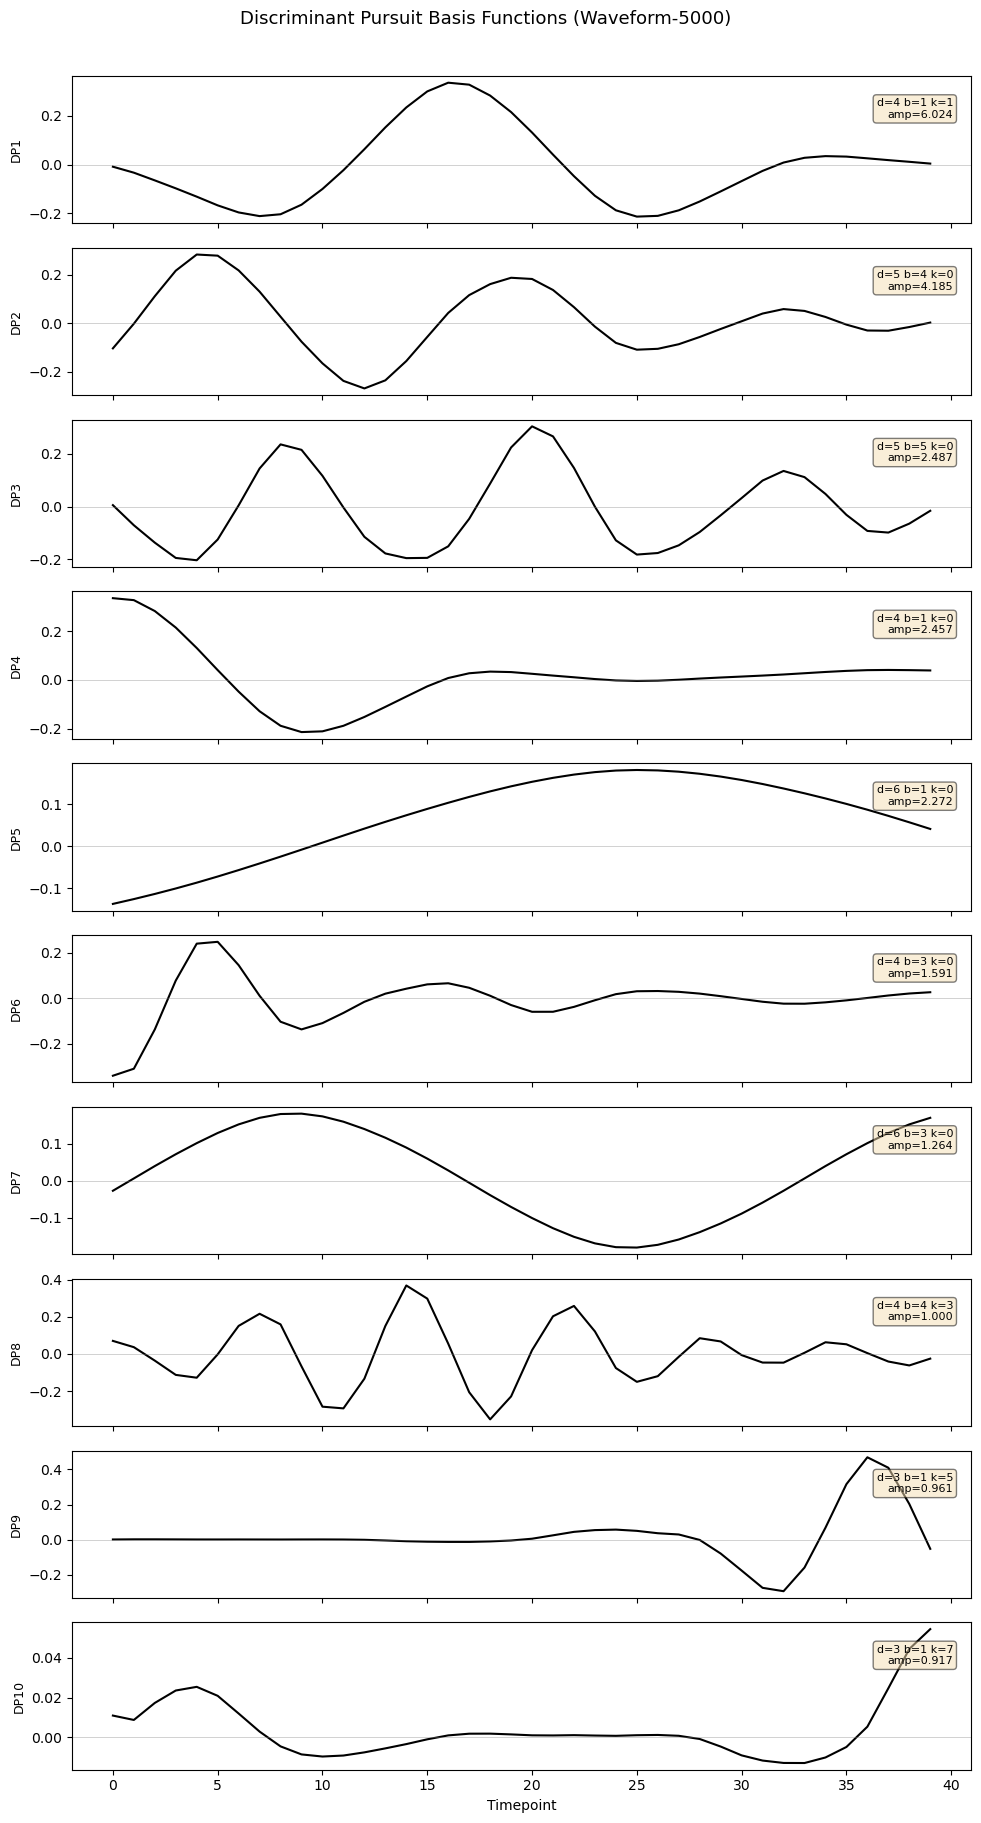

In [5]:
n_show = min(10, len(dp['basis_functions']))
fig, axes = plt.subplots(n_show, 1, figsize=(10, 1.8 * n_show), sharex=True)

for i in range(n_show):
    ax = axes[i]
    bf = dp['basis_functions'][i]
    d, b, k = dp['packet_indices'][i]

    # Only show the original 40 timepoints
    ax.plot(bf[:40], color='black', linewidth=1.5)
    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.set_ylabel(f'DP{i+1}', fontsize=9)

    ax.text(0.98, 0.85,
            f'd={d} b={b} k={k}\namp={dp["amplitudes"][i]:.3f}',
            transform=ax.transAxes, fontsize=8, ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))

axes[-1].set_xlabel('Timepoint')
fig.suptitle('Discriminant Pursuit Basis Functions (Waveform-5000)',
             fontsize=13, y=1.01)
plt.tight_layout()

## 5. Basis functions overlaid on class means

Show where each basis function is localized relative to the class
structure. The basis function amplitude is scaled for visibility.

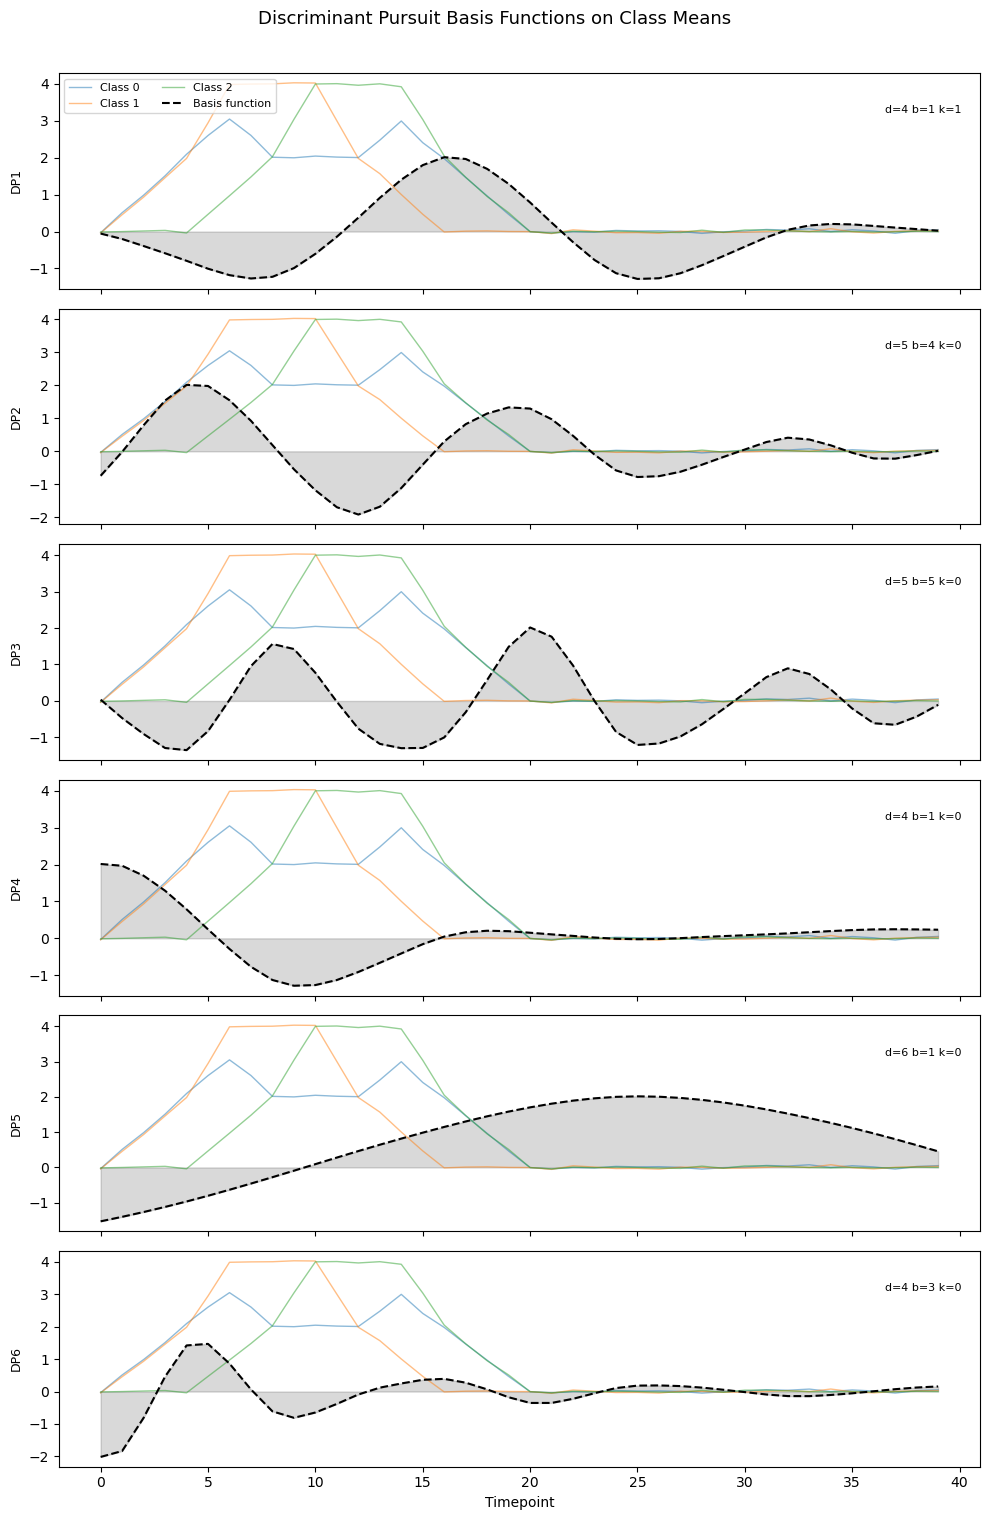

In [6]:
n_classes = len(np.unique(y))
colors = ['tab:blue', 'tab:orange', 'tab:green']
class_labels = [f'Class {k}' for k in range(n_classes)]

# Compute class means (original 40 timepoints)
class_means_raw = []
for k in range(n_classes):
    mask = y_train == k
    class_means_raw.append(X_train[mask, :40].mean(axis=0))

n_show_overlay = min(6, len(dp['basis_functions']))
fig, axes = plt.subplots(n_show_overlay, 1, figsize=(10, 2.5 * n_show_overlay),
                         sharex=True)

for i in range(n_show_overlay):
    ax = axes[i]
    bf = dp['basis_functions'][i][:40]
    d, b, k_pkt = dp['packet_indices'][i]

    # Plot class means
    for k in range(n_classes):
        ax.plot(class_means_raw[k], color=colors[k], alpha=0.5, linewidth=1,
                label=class_labels[k] if i == 0 else None)

    # Overlay basis function (scaled for visibility)
    scale = np.max(np.abs(np.array(class_means_raw))) * 0.5
    bf_scaled = bf / np.max(np.abs(bf)) * scale if np.max(np.abs(bf)) > 0 else bf
    ax.fill_between(range(40), 0, bf_scaled, color='black', alpha=0.15)
    ax.plot(bf_scaled, color='black', linewidth=1.5, linestyle='--',
            label='Basis function' if i == 0 else None)

    ax.set_ylabel(f'DP{i+1}', fontsize=9)
    ax.text(0.98, 0.85, f'd={d} b={b} k={k_pkt}',
            transform=ax.transAxes, fontsize=8, ha='right', va='top')

    if i == 0:
        ax.legend(fontsize=8, loc='upper left', ncol=2)

axes[-1].set_xlabel('Timepoint')
fig.suptitle('Discriminant Pursuit Basis Functions on Class Means',
             fontsize=13, y=1.01)
plt.tight_layout()

## 6. Temporal coverage of discriminant basis functions

The energy profile of each basis function shows its temporal support.
This is accomplished by summing across basis functions (weighted by 
amplitude) giving an aggregate temporal importance measure.

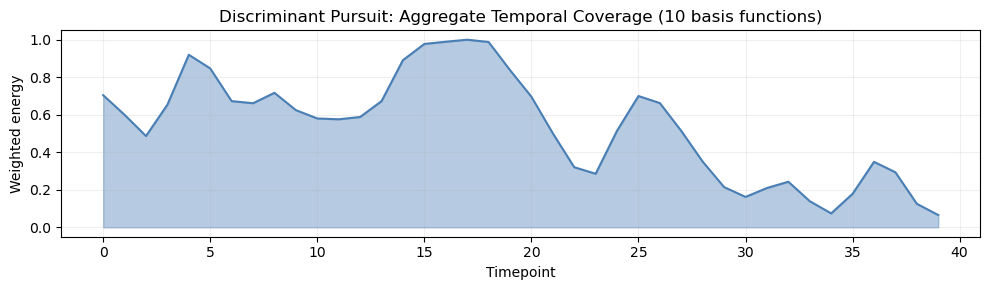

In [7]:
n_timepoints = 40
coverage = np.zeros(n_timepoints)

for i in range(len(dp['basis_functions'])):
    bf = dp['basis_functions'][i][:n_timepoints]
    amp = dp['amplitudes'][i]
    coverage += amp * bf ** 2  # energy weighted by amplitude

# Normalize
if coverage.max() > 0:
    coverage /= coverage.max()

fig, ax = plt.subplots(figsize=(10, 3))
ax.fill_between(range(n_timepoints), coverage, color='#4A7FB5', alpha=0.4)
ax.plot(coverage, color='#4A7FB5', linewidth=1.5)
ax.set_xlabel('Timepoint')
ax.set_ylabel('Weighted energy')
ax.set_title('Discriminant Pursuit: Aggregate Temporal Coverage '
             f'({len(dp["basis_functions"])} basis functions)')
ax.grid(True, alpha=0.2)
plt.tight_layout()

## 7. Feature distributions by class

The discriminant pursuit coefficients, i.e., projections of each trial 
onto the selected basis functions, should show class separation if the
basis functions are genuinely discriminative.

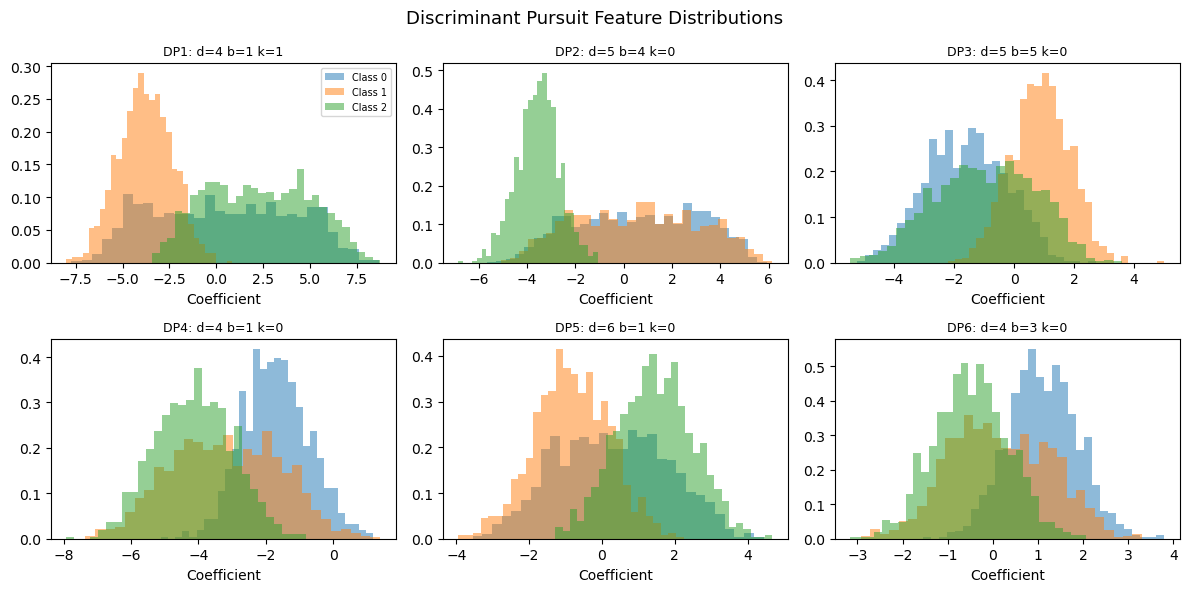

In [8]:
n_show_dist = min(6, dp['train_coefs'].shape[1])
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for i in range(n_show_dist):
    ax = axes[i]
    d, b, k_pkt = dp['packet_indices'][i]

    for k in range(n_classes):
        mask = y_train == k
        ax.hist(dp['train_coefs'][mask, i], bins=30, alpha=0.5,
                color=colors[k], label=class_labels[k], density=True)

    ax.set_title(f'DP{i+1}: d={d} b={b} k={k_pkt}', fontsize=9)
    if i == 0:
        ax.legend(fontsize=7)
    ax.set_xlabel('Coefficient')

fig.suptitle('Discriminant Pursuit Feature Distributions', fontsize=13)
plt.tight_layout()

## 8. Accuracy as a function of number of basis functions

How many discriminant pursuit basis functions are needed for good
classification? 


Accuracy with 1 basis function:  0.5960
Accuracy with 5 basis functions: 0.8673
Accuracy with 10 basis functions: 0.8673


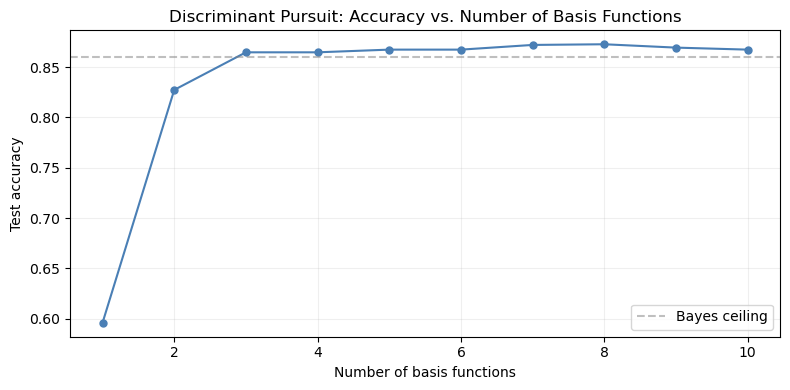

In [9]:
n_max = len(dp['basis_functions'])
accs = []

for n_use in range(1, n_max + 1):
    sc = StandardScaler()
    tr = sc.fit_transform(dp['train_coefs'][:, :n_use])
    te = sc.transform(dp['test_coefs'][:, :n_use])
    c = RidgeClassifierCV(alphas=np.logspace(-10, 10, 20))
    c.fit(tr, y_train)
    pred = c.predict(te)
    accs.append(accuracy_score(y_test, pred))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, n_max + 1), accs, 'o-', color='#4A7FB5', linewidth=1.5,
        markersize=5)
ax.axhline(0.86, color='gray', linestyle='--', alpha=0.5, label='Bayes ceiling')
ax.set_xlabel('Number of basis functions')
ax.set_ylabel('Test accuracy')
ax.set_title('Discriminant Pursuit: Accuracy vs. Number of Basis Functions')
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout() 

print(f"\nAccuracy with 1 basis function:  {accs[0]:.4f}")
print(f"Accuracy with 5 basis functions: {accs[4]:.4f}")
print(f"Accuracy with {n_max} basis functions: {accs[-1]:.4f}")